# Creating midgut Seurat integrated object containing spliced and unspliced counts

**Purpose**

In this notebook, we integrate midgut cells from four independent single-cell RNA-seq datasets using Seurat’s integration framework. All datasets were preprocessed with the Velocyto pipeline and contain matched spliced and unspliced count matrices, enabling downstream RNA velocity analysis.


**Input data**

The input to this workflow is composed of two complementary data representations of the same cells.

* The first representation contains only gene expression data and corresponds to the full datasets that were previously integrated using Harmony. These objects do not contain spliced or unspliced layers and are used as the basis for dimensionality reduction and graph construction.
* The second representation consists of the midgut cells from each dataset separately, and in addition to gene expression counts, includes the corresponding spliced and unspliced matrices generated by the Velocyto pipeline.


**Workflow overview**

To enable joint analysis, the Harmony-integrated expression matrix from the first representation is subsetted to match the genes and cells present in the second representation. This subsetted matrix is then used as input for Seurat anchor-based integration across the four datasets.

The batch-corrected expression matrix obtained from Seurat is subsequently merged back into the first representation, which is then used to construct the neighbor graph and perform dimensionality reduction. This strategy is required because the spliced and unspliced layers are not directly compatible with conversion to Seurat objects.


**Output**

The final outputs of this notebook is an integrated low-dimensional representation (UMAP) of all midgut cells together with the spliced and unspliced counts that can be used for downstream analysis including RNA velocity.


**Saved files**

`mg_6_7_8_9_raw_velo.h5ad` - anndata object of midgut cells with raw counts and spliced/unspliced layers
`mg_6_7_8_9_velo_refint.h5ad` - anndata object of midgut cells with spliced/unspliced layers after Seurat integration


In [ ]:
import os
import random

import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

from scipy.sparse import csr_matrix, issparse

from scipy import io

sc.settings.set_figure_params(dpi=80, frameon=False)
sc.set_figure_params(dpi=80)
sc.set_figure_params(figsize=(4, 4))
plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (4, 4)

from scipy.sparse import csr_matrix, issparse

import anndata as ad

# R interface
from rpy2.robjects import pandas2ri
from rpy2.robjects import r
import rpy2.rinterface_lib.callbacks
import anndata2ri

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython


In [ ]:
SEED = 0

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
%%R
set.seed(0)
# R packages
library(Seurat)

In [43]:
%%R
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS Ventura 13.5.1

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Users/royaab/miniconda3/envs/scrnaseq-dros_manuscript/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C/UTF-8/C/C/C/C

time zone: Europe/Berlin
tzcode source: system (macOS)

attached base packages:
[1] tools     stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
[1] Seurat_5.3.0       SeuratObject_5.2.0 sp_2.2-0          

loaded via a namespace (and not attached):
  [1] deldir_2.0-4           pbapply_1.7-4          gridExtra_2.3         
  [4] rlang_1.1.6            magrittr_2.0.3         RcppAnnoy_0.0.22      
  [7] matrixStats_1.5.0      ggridges_0.5.7         compiler_4.3.3        
 [10] spatstat.geom_3.5-0    png_0.1-8              vctrs_0.6.5           
 [

In [4]:
sc.set_figure_params(dpi=160)
sc.set_figure_params(figsize=(4, 4))
plt.rcParams['figure.dpi'] = 160
plt.rcParams['figure.figsize'] = (4, 4)

In [ ]:
adata=sc.read('../data/processed/WT_Harmony.h5ad')
adata

In [ ]:
adata.X = adata.layers['raw_counts'].copy()
adata.X

In [ ]:
adata.X

In [ ]:
sc.pl.umap(adata, color=['batch', 'celltype'])

The following datasets (chipX) only have midgut cells.

In [ ]:
chip6=sc.read('../data/processed/mg_chip6_raw_velo.h5ad')
chip7=sc.read('../data/processed/mg_chip7_raw.h5ad')
chip8=sc.read('../data/processed/mg_chip8_raw.h5ad')
chip9=sc.read('../data/processed/mg_chip9_raw.h5ad')

In [ ]:
chip6.obs['batch']='WT_01'
chip7.obs['batch']='WT_02'
chip8.obs['batch']='WT_03'
chip9.obs['batch']='WT_04'

In [ ]:
chip7

In [ ]:
chip8

In [ ]:
chip6

In [ ]:
chip9

In [ ]:
chip6.obs=chip6.obs.set_index(chip6.obs['barcode'])

* create two adata objects one named adata_velo, the other called adata_subset with the exact number and order of genes and cells.
* adata_velo contains the information about the spliced and unspliced counts
* adata_subset is used for seurat data integration (that is because the layers in adata_velo are not compatible with converting to Seurat object)

In [ ]:
adata_velo=chip6.concatenate(chip7, chip8, chip9, batch_key='batch', batch_categories=['WT_01', 'WT_02', 'WT_03', 'WT_04'], index_unique='-')
adata_velo

In [ ]:
adata_velo.write('mg_6_7_8_9_raw_velo.h5ad')

In [ ]:
common_cells = adata.obs_names[adata.obs_names.isin(adata_velo.obs_names)]
common_genes = adata.var_names[adata.var_names.isin(adata_velo.var_names)]

# Subset 'adata1' to only include the common cells
adata_subset = adata[common_cells, common_genes].copy()

In [ ]:
adata_subset

In [ ]:
# Reorder cells in adata2 to match the order in adata1
adata_velo = adata_velo[adata_subset.obs_names, :]

# Reorder genes in adata2 to match the order in adata1
adata_velo = adata_velo[:, adata_subset.var_names]


In [ ]:
adata_subset.X

In [ ]:
adata_velo.X

In [ ]:
sc.pp.normalize_total(adata_subset, target_sum=None)
sc.pp.log1p(adata_subset)

In [ ]:
adata_subset.layers['logcounts']=adata_subset.X.copy()

In [ ]:
sc.pp.highly_variable_genes(adata_subset, batch_key='batch', n_top_genes=4000)
sc.pp.pca(adata_subset, n_comps=30)
sc.pp.neighbors(adata_subset, n_pcs=30)
sc.tl.umap(adata_subset)

In [ ]:
sc.pl.umap(adata_subset, color=['batch'])

In [ ]:
sc.pl.umap(adata_subset, color=['batch'])

In [ ]:
adata_hvg = adata_subset[:, adata_subset.var["highly_variable"]].copy()

In [ ]:
adata_hvg.var['mt'].sum()

Excluding mitochondrial genes from highly variable genes

In [ ]:
adata_hvg = adata_hvg[:, adata_hvg.var['mt'] == False]
adata_hvg

In [ ]:
#subset the genes in adata_velo 
adata_velo_hvg = adata_velo[:, adata_hvg.var_names].copy()
adata_velo_hvg

In [ ]:
adata_seu=adata_hvg.copy()

In [ ]:
adata_seu.X=adata_seu.layers['raw_counts'].copy()

In [ ]:
adata_velo_hvg.X

In [ ]:
adata_velo_hvg.layers['raw_counts']=adata_velo_hvg.X.copy()

In [ ]:
adata_seu.X

In [ ]:
adata_seu

In [ ]:
# Convert categorical columns to strings
adata_seu.obs['batch'] = adata_seu.obs['batch'].astype(str)
adata_seu.obs['celltype']=adata_seu.obs['celltype'].astype(str)
# Delete uns as this can contain arbitrary objects which are difficult to convert
del adata_seu.uns
adata_seu

In [ ]:
%%R -i adata_seu
adata_seu

In [ ]:
%%R -i adata_seu
seurat <- as.Seurat(adata_seu, counts = "raw_counts", data = "logcounts")
seurat

In [ ]:
batch_key='batch'

In [ ]:
%%R -i batch_key
batch_list <- SplitObject(seurat, split.by = batch_key)
batch_list

In [ ]:
%%R
anchors <- FindIntegrationAnchors(batch_list, anchor.features = rownames(seurat), dims=1:30)
anchors

In [ ]:
%%R
integrated <- IntegrateData(anchors, dims=1:30)
integrated

In [ ]:
%%R
integrated

In [ ]:
%%R -o integrated_expr
# Extract the integrated expression matrix
integrated_expr <- GetAssayData(integrated)
# Make sure the rows and columns are in the same order as the original object
integrated_expr <- integrated_expr[rownames(seurat), colnames(seurat)]
# Transpose the matrix to AnnData format
integrated_expr <- t(integrated_expr)
print(integrated_expr[1:10, 1:10])

In [ ]:
adata_velo_hvg

In [ ]:
adata_velo_hvg.X = integrated_expr
adata_velo_hvg.layers["seurat"] = integrated_expr
print(adata_velo_hvg)

In [ ]:
adata_velo_hvg.X.toarray()

In [ ]:
# Reset the batch colours because we deleted them earlier
adata_velo_hvg.uns[batch_key + "_colors"] = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
]

In [ ]:
sc.pp.pca(adata_velo_hvg)

In [ ]:
sc.pp.neighbors(adata_velo_hvg,n_pcs=27, n_neighbors=10)
#sc.tl.umap(adata_velo_hvg, n_components=2)

In [ ]:
sc.tl.umap(adata_velo_hvg, min_dist=0.4)

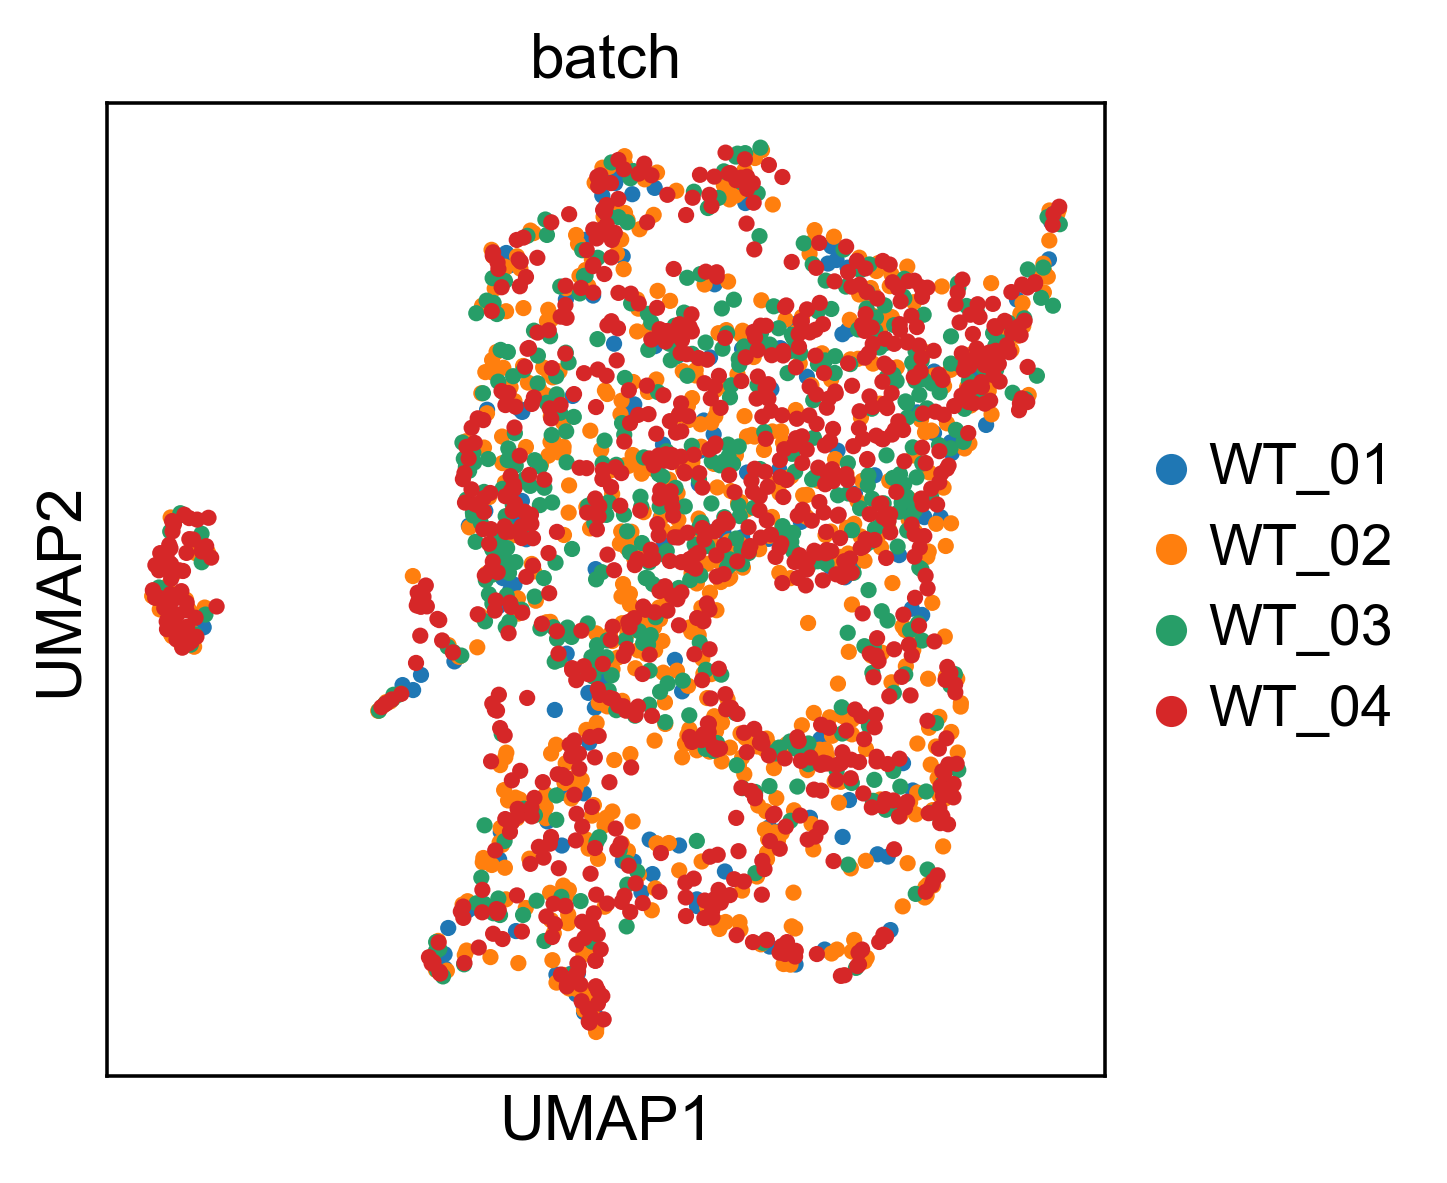

In [98]:
sc.pl.umap(adata_velo_hvg, color=[ batch_key])

In [ ]:
sc.pl.pca_variance_ratio(adata_velo_hvg, n_pcs=50)

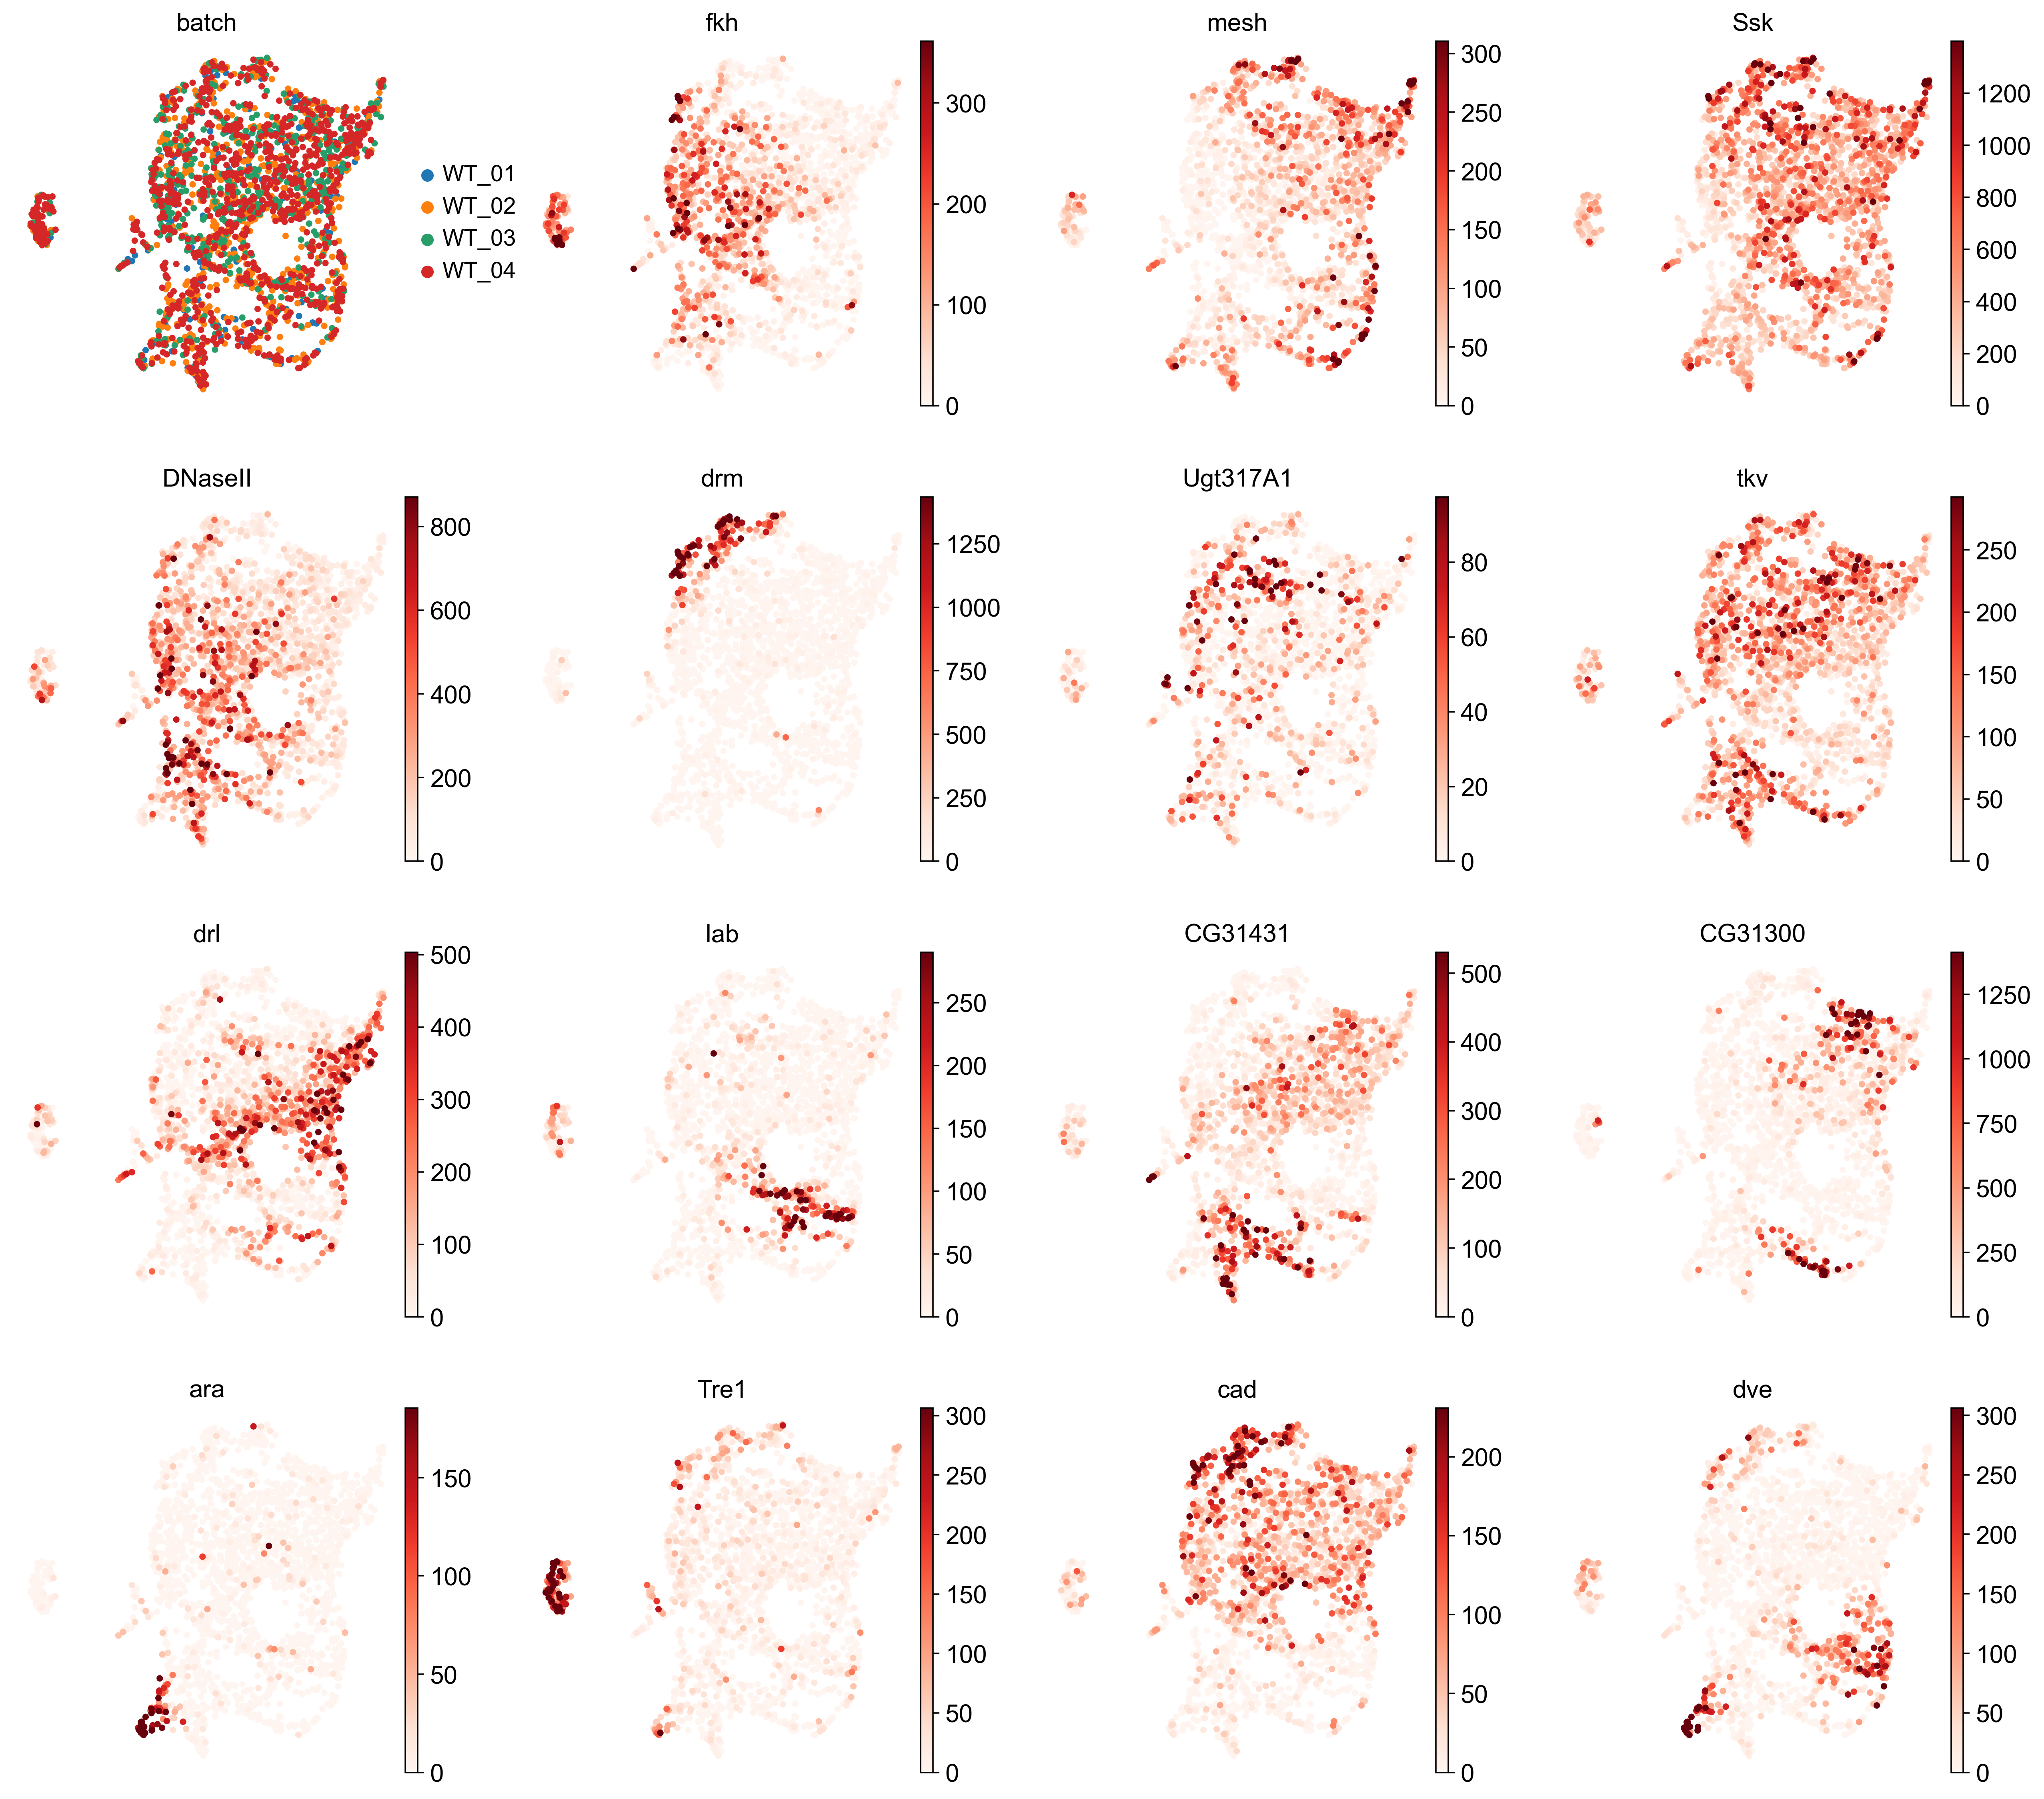

In [99]:
sc.pl.umap(adata_velo_hvg, color=['batch', 'fkh', 'mesh','Ssk', 'DNaseII', 'drm', 'Ugt317A1', 'tkv', 'drl', 'lab', 'CG31431', 'CG31300', 
                                  'ara', 'Tre1', 'cad', 'dve'],
           layer='raw_counts',
           cmap= 'Reds',
          frameon=False, vmax='p99', vmin=0)

In [ ]:
sc.tl.leiden(adata_velo_hvg, resolution=0.1, key_added='leiden_0.1')
sc.tl.leiden(adata_velo_hvg, resolution=0.15, key_added='leiden_0.15')
sc.tl.leiden(adata_velo_hvg, resolution=0.2, key_added='leiden_0.2')

In [ ]:
sc.tl.leiden(adata_velo_hvg, resolution=0.3, key_added='leiden_0.3')
sc.tl.leiden(adata_velo_hvg, resolution=0.5, key_added='leiden_0.5')

In [ ]:
sc.tl.leiden(adata_velo_hvg, resolution=0.7, key_added='leiden_0.7')
sc.tl.leiden(adata_velo_hvg, resolution=0.9, key_added='leiden_0.9')
sc.tl.leiden(adata_velo_hvg, resolution=1, key_added='leiden_1')
sc.tl.leiden(adata_velo_hvg, resolution=1.2, key_added='leiden_1.2')
sc.tl.leiden(adata_velo_hvg, resolution=1.4, key_added='leiden_1.4')

In [ ]:
adata_velo_hvg = sc.read("../data/processed/mg_6_7_8_9_velo_refint.h5ad")

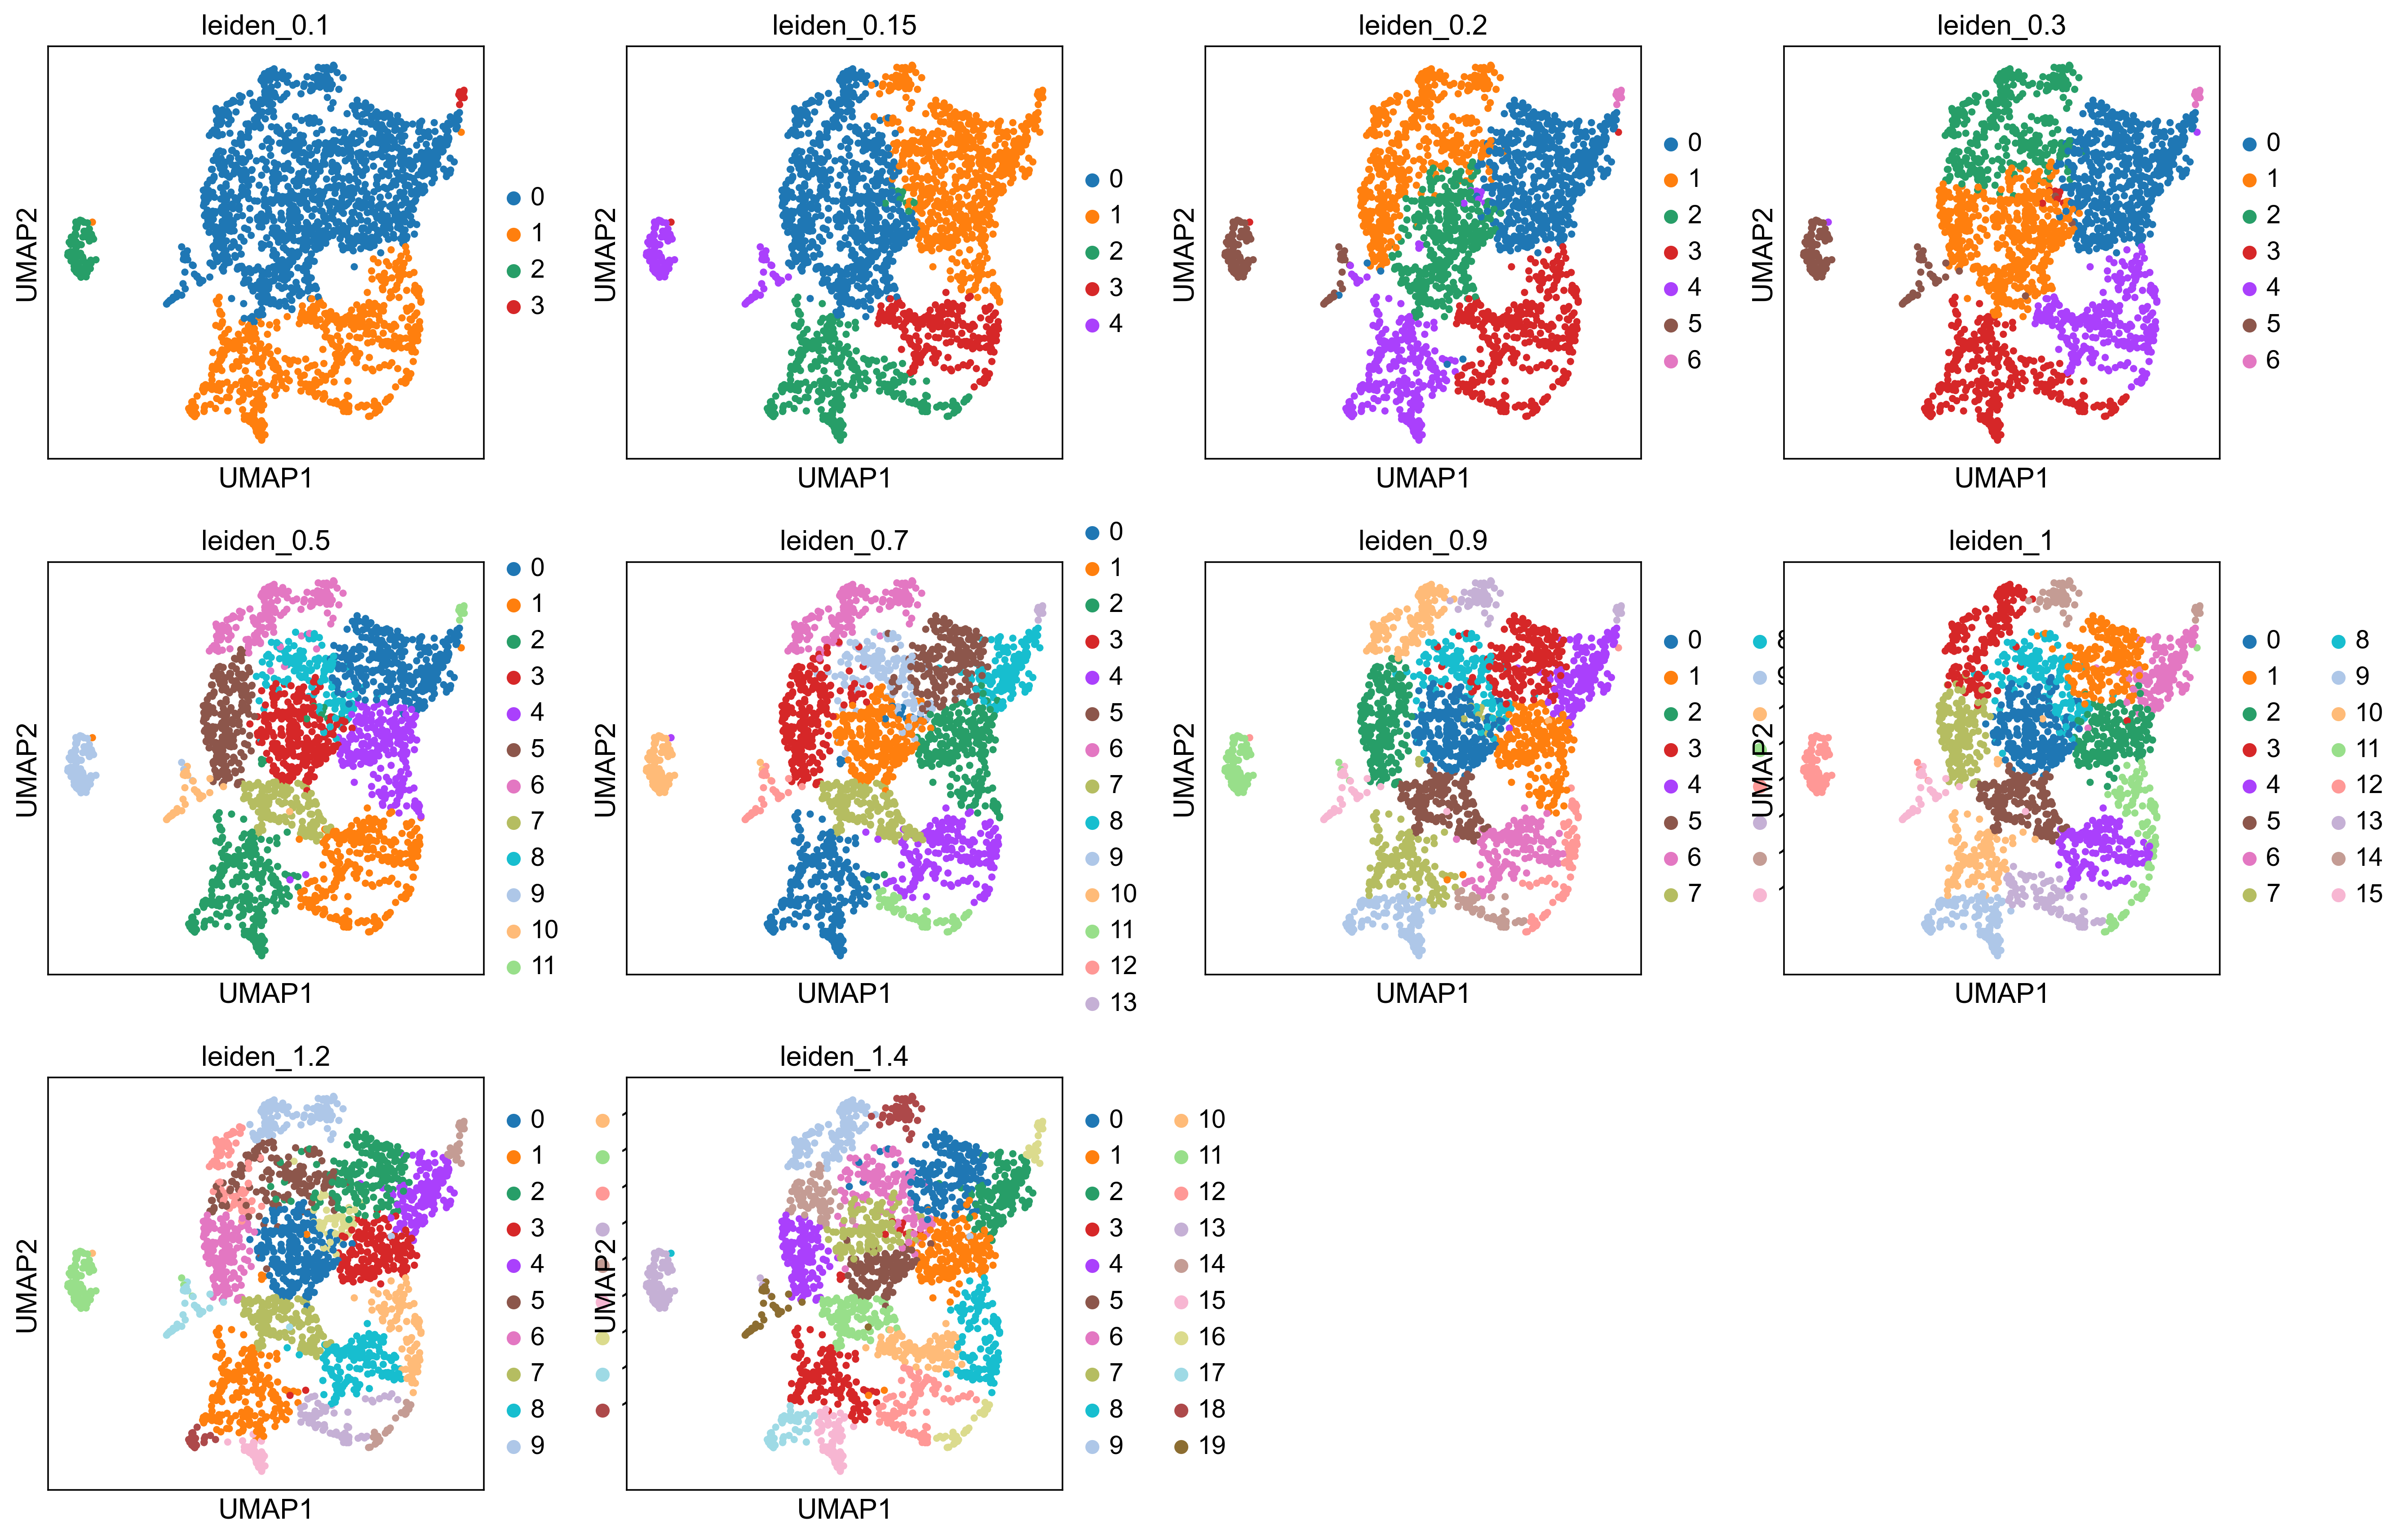

In [97]:
sc.pl.umap(adata_velo_hvg, color=['leiden_0.1', 'leiden_0.15', 'leiden_0.2','leiden_0.3', 'leiden_0.5','leiden_0.7', 'leiden_0.9', 'leiden_1', 'leiden_1.2', 'leiden_1.4'])

In [ ]:
adata_velo_hvg.write('mg_6_7_8_9_velo_refint.h5ad')